# 02 — Clustering Pipeline

This notebook implements the clustering pipeline (Epic 3+) for Sephora customer segmentation.

**Sections:**
- E3.1 Feature Selection
- E3.2 Missing-value imputation *(upcoming)*
- E3.3 Feature scaling *(upcoming)*
- E3.4 PCA variance analysis *(upcoming)*
- E3.5 UMAP 2-D visualization *(upcoming)*

In [1]:
import pandas as pd
import numpy as np
from src.config import (
    DATA_PROCESSED_PATH,
    CLUSTERING_FEATURES,          # legacy – kept for backward compatibility
    FEATURES_DROP,
    FEATURES_CONTINUOUS,
    FEATURES_ONEHOT,
    FEATURES_FREQUENCY,
)

## E3.1 — Feature Selection Audit (US-3.1)

All 54 columns of `customers_features.csv` are classified below.
**Fate legend:** `Keep` → retained in preprocessing pipeline | `Drop` → removed before modelling.

### Complete Feature Audit (54 columns → 40 retained → ~70 after encoding)

| Feature | Fate | Group | Family | Reason |
|---|---|---|---|---|
| `recency_days` | Keep | Continuous | RFM | Core recency metric (days since last purchase) |
| `frequency` | Keep | Continuous | RFM | Core frequency metric (number of transactions) |
| `frequency_capped` | **Drop** | — | RFM | Winsorized duplicate of `frequency` |
| `monetary_total` | Keep | Continuous | RFM | Total lifetime spend |
| `monetary_total_capped` | **Drop** | — | RFM | Winsorized duplicate of `monetary_total` |
| `monetary_avg` | Keep | Continuous | RFM | Average spend per visit |
| `total_sales_eur` | **Drop** | — | RFM | Exact duplicate of `monetary_total` |
| `avg_sales_eur` | **Drop** | — | RFM | Exact duplicate of `monetary_avg` |
| `total_transactions` | **Drop** | — | RFM | Exact duplicate of `frequency` |
| `avg_basket_size_eur` | Keep | Continuous | Behavior | Average basket value (EUR) |
| `avg_units_per_basket` | Keep | Continuous | Behavior | Units per transaction — shopping intensity |
| `discount_rate` | Keep | Continuous | Behavior | Discount sensitivity ratio |
| `total_discount_eur` | Keep | Continuous | Behavior | Absolute discount volume |
| `total_quantity` | Keep | Continuous | Behavior | Total units purchased |
| `total_lines` | Keep | Continuous | Behavior | Transaction line count |
| `store_ratio` | Keep | Continuous | Channel | In-store purchase proportion |
| `estore_ratio` | Keep | Continuous | Channel | Online purchase proportion |
| `click_collect_ratio` | Keep | Continuous | Channel | Click & collect proportion |
| `cc_transactions` | Keep | Continuous | Channel | Click & collect transaction count |
| `dominant_channel` | Keep | One-Hot | Channel | Dominant channel category (3 modalities) |
| `channel_recruitment` | Keep | One-Hot | Channel | Acquisition channel (3 modalities) |
| `first_purchase_channel` | **Drop** | — | Channel | Exact duplicate of `channel_recruitment` |
| `axe_make_up_ratio` | Keep | Continuous | Product | Make-up affinity ratio |
| `axe_skincare_ratio` | Keep | Continuous | Product | Skincare affinity ratio |
| `axe_fragrance_ratio` | Keep | Continuous | Product | Fragrance affinity ratio |
| `axe_haircare_ratio` | Keep | Continuous | Product | Haircare affinity ratio |
| `axe_others_ratio` | Keep | Continuous | Product | Other axes affinity ratio |
| `axis_diversity` | Keep | Continuous | Product | Number of distinct product axes |
| `nb_unique_brands` | Keep | Continuous | Product | Brand breadth |
| `nb_unique_stores` | Keep | Continuous | Product | Store diversity |
| `dominant_axe` | Keep | One-Hot | Product | Dominant product category (5 modalities) |
| `first_purchase_axe` | Keep | One-Hot | Product | First purchase category (6 modalities) |
| `Axe_Desc_first_purchase` | **Drop** | — | Product | Raw string — `first_purchase_axe` retained |
| `market_selective_ratio` | Keep | Continuous | Product | Selective market share |
| `market_exclusive_ratio` | Keep | Continuous | Product | Exclusive market share |
| `market_sephora_ratio` | Keep | Continuous | Product | Sephora market share |
| `market_others_ratio` | Keep | Continuous | Product | Other markets share |
| `dominant_market` | Keep | One-Hot | Product | Dominant market category (4 modalities) |
| `gender` | Keep | One-Hot | Sociodemographic | Customer gender (3 modalities) |
| `age` | Keep | Continuous | Sociodemographic | Customer age (years) |
| `age_category` | Keep | One-Hot | Sociodemographic | Age band (5 modalities) |
| `age_generation` | Keep | One-Hot | Sociodemographic | Generational cohort (5 modalities) |
| `country` | Keep | One-Hot | Sociodemographic | Country of residence (3 modalities) |
| `customer_city` | Keep | Frequency | Sociodemographic | City (~12K unique → urbanization proxy) |
| `loyalty_numeric` | Keep | Continuous | Sociodemographic | Loyalty tier ordinal (0 No-Fid → 3 Gold) |
| `loyalty_status` | **Drop** | — | Sociodemographic | String version of `loyalty_numeric` |
| `subscription_tenure_days` | Keep | Continuous | Lifecycle | Loyalty program age (days) |
| `subscription_date` | **Drop** | — | Lifecycle | Raw date — `subscription_tenure_days` retained |
| `first_purchase_amount` | Keep | Continuous | Lifecycle | First transaction value (EUR) |
| `first_purchase_date` | **Drop** | — | Lifecycle | Raw date — derivatives retained |
| `salesVatEUR_first_purchase` | **Drop** | — | Lifecycle | Exact duplicate of `first_purchase_amount` |
| `last_purchase_date` | **Drop** | — | Lifecycle | Raw date — `recency_days` retained |
| `is_new_customer` | **Drop** | — | Lifecycle | Zero variance (constant = 1 for all rows) |
| `is_outlier` | **Drop** | — | Traceability | Operational flag — not a behavioral feature |

### Summary

| Fate | Count | Post-encoding dimensions |
|---|---|---|
| Dropped | 14 | 0 |
| Continuous | 30 | 30 (after StandardScaler) |
| One-Hot | 9 | ~37 (Unknown + OHE) |
| Frequency | 1 | 1 |
| *Created* | *+2* | *+2 (`has_age_info`, `has_first_purchase_info`)* |
| **Total** | **54 → 40** | **~70** |

In [2]:
df_customers = pd.read_csv(DATA_PROCESSED_PATH + "customers_features.csv")
print(f"Loaded customers_features.csv: {df_customers.shape}")

Loaded customers_features.csv: (64469, 54)


In [3]:
all_retained = FEATURES_CONTINUOUS + FEATURES_ONEHOT + FEATURES_FREQUENCY

print(f"Dataset : {df_customers.shape[0]:,} customers × {df_customers.shape[1]} raw columns")
print(f"\nFeature audit:")
print(f"  Dropped     : {len(FEATURES_DROP):>2}  (zero-var, dupes, raw dates, flags)")
print(f"  Continuous  : {len(FEATURES_CONTINUOUS):>2}  → median imputation + StandardScaler")
print(f"  One-Hot     : {len(FEATURES_ONEHOT):>2}  → 'Unknown' fill + OHE")
print(f"  Frequency   : {len(FEATURES_FREQUENCY):>2}  → Frequency Encoding")
print(f"\n  Total retained : {len(all_retained)} features  (~70 after encoding)")

# Validate all retained features are present in the dataset
missing = [f for f in all_retained if f not in df_customers.columns]
if missing:
    print(f"\n⚠  Missing features: {missing}")
else:
    print(f"\n✓  All {len(all_retained)} retained features found in dataset")

# Build X_raw from all retained features (downstream E3.2 / E3.3 use this)
X_raw = df_customers[all_retained].copy()
print(f"\nX_raw shape: {X_raw.shape}")

Dataset : 64,469 customers × 54 raw columns

Feature audit:
  Dropped     : 14  (zero-var, dupes, raw dates, flags)
  Continuous  : 30  → median imputation + StandardScaler
  One-Hot     :  9  → 'Unknown' fill + OHE
  Frequency   :  1  → Frequency Encoding

  Total retained : 40 features  (~70 after encoding)

✓  All 40 retained features found in dataset

X_raw shape: (64469, 40)


In [4]:
X_raw.describe().round(2)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _e

,recency_days,frequency,monetary_total,monetary_avg,avg_basket_size_eur,avg_units_per_basket,discount_rate,total_discount_eur,total_quantity,total_lines,...,market_sephora_ratio,market_others_ratio,nb_unique_brands,nb_unique_stores,axis_diversity,cc_transactions,age,subscription_tenure_days,first_purchase_amount,loyalty_numeric
count,64469.00,64469.00,64469.00,64469.00,64469.00,64469.00,64469.00,64469.00,64469.00,64469.00,...,64469.00,64469.00,64469.00,64469.00,64469.00,64469.00,55852.00,63966.00,24051.00,64469.00
mean,111.44,3.00,198.13,40.20,69.54,2.01,0.12,25.97,6.19,6.20,...,-inf,inf,3.26,1.64,1.92,0.00,39.80,2900.08,77.59,1.38
std,106.16,3.69,308.26,32.75,64.93,1.53,0.15,70.89,9.44,9.52,...,NaN,NaN,3.46,1.11,1.09,0.02,15.67,2493.53,94.31,0.56
min,0.00,1.00,-196.92,-132.00,-196.92,-4.00,-0.00,-1126.40,-4.00,1.00,...,-inf,-7.14,1.00,1.00,1.00,0.00,15.00,-65.00,-693.00,1.00
25%,22.00,1.00,50.00,18.88,31.74,1.00,0.00,0.00,1.00,1.00,...,0.00,0.00,1.00,1.00,1.00,0.00,26.00,621.00,27.93,1.00
50%,68.00,2.00,108.28,29.45,54.34,1.59,0.04,5.00,3.00,3.00,...,0.06,0.00,2.00,1.00,2.00,0.00,38.00,2200.00,55.97,1.00
75%,186.00,3.00,225.90,50.00,88.85,2.33,0.22,33.75,7.00,7.00,...,0.30,0.00,4.00,2.00,2.00,0.00,50.00,5034.75,97.46,2.00
max,364.00,115.00,10955.15,699.00,2893.90,39.00,1.00,3441.40,254.00,244.00,...,21.65,inf,57.00,16.00,6.00,5.00,100.00,8096.00,2989.00,3.00


## E3.2 — Missing Value Imputation (US-3.2 REVISED)

### Imputation Decisions

| Feature | Missing % | Strategy | Rationale |
|---|---|---|---|
| `age` | 13.4% | **Median** + `has_age_info` indicator | Missing age may signal online-only / privacy-conscious customers |
| `subscription_tenure_days` | 0.8% | **Median** | Preserves relative ranking; 0 would falsely imply no subscription |
| `first_purchase_amount` | 62.7% | **Median** + `has_first_purchase_info` indicator | Kept (not dropped) — missingness is systematic and informative |
| `channel_recruitment` | 62.7% | **`'Unknown'`** | Explicit category avoids bias toward existing categories |
| `age_category` | 30.5% | **`'Unknown'`** | Derived from `age` — missingness is coherent |
| `age_generation` | 32.5% | **`'Unknown'`** | Derived from `age` — missingness is coherent |
| `first_purchase_axe` | 62.7% | **`'Unknown'`** (after axis cleaning) | 6 primary axes: MAKE UP, SKINCARE, FRAGRANCE, HAIRCARE, OTHERS, Unknown |
| `customer_city` | 5.2% | **`'Unknown'`** | Low missingness — explicit category sufficient |
| Ratio columns (×7) | — | **`inf → 0.0`** | Division-by-zero upstream — zero ratio is the correct semantic |

### Key Changes vs Previous Approach

- **`first_purchase_amount` is KEPT** (was dropped at 62.7% threshold): we now impute with median and capture missingness via `has_first_purchase_info`
- **Missing indicators created BEFORE imputation**: `has_age_info` (0/1), `has_first_purchase_info` (0/1)
- **`first_purchase_axe` cleaned** to 6 primary axes via pipe-split + MAEK UP typo fix

In [5]:
import importlib
import src.preprocessing
importlib.reload(src.preprocessing)
from src.preprocessing import preprocess_for_clustering

# --- AC-1: Imputation summary before preprocessing ---
all_retained = FEATURES_CONTINUOUS + FEATURES_ONEHOT + FEATURES_FREQUENCY
raw_cols = [c for c in all_retained if c in df_customers.columns]
missing_before = df_customers[raw_cols].isnull().mean()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print("=== Missing Rate per Feature (BEFORE imputation) ===")
for col, rate in missing_before.items():
    count = df_customers[col].isnull().sum()
    print(f"  {col:40s}: {count:6d} NaN ({rate * 100:.1f}%)")

print("\n--- Running preprocess_for_clustering() ---\n")
X_preprocessed = preprocess_for_clustering(df_customers)

# --- AC-7: Zero NaN confirmed ---
assert X_preprocessed.isnull().sum().sum() == 0, "NaN values remain after preprocessing"
print(f"\n✓ Zero NaN confirmed — X_preprocessed shape: {X_preprocessed.shape}")

=== Missing Rate per Feature (BEFORE imputation) ===
  first_purchase_amount                   :  40418 NaN (62.7%)
  channel_recruitment                     :  40418 NaN (62.7%)
  first_purchase_axe                      :  40418 NaN (62.7%)
  age_generation                          :  20937 NaN (32.5%)
  age_category                            :  19638 NaN (30.5%)
  age                                     :   8617 NaN (13.4%)
  customer_city                           :   3371 NaN (5.2%)
  subscription_tenure_days                :    503 NaN (0.8%)

--- Running preprocess_for_clustering() ---

=== Missing Rate per Feature ===
  age: 8617 missing (13.37%)
  age_category: 19638 missing (30.46%)
  age_generation: 20937 missing (32.48%)
  customer_city: 3371 missing (5.23%)
  subscription_date: 503 missing (0.78%)
  channel_recruitment: 40418 missing (62.69%)
  salesVatEUR_first_purchase: 40418 missing (62.69%)
  Axe_Desc_first_purchase: 40418 missing (62.69%)
  subscription_tenure_days: 5

## E3.3 — Multi-Encoding & Scaling Pipeline (US-3.3 REVISED)

### Encoding Decisions per Feature Type

| Encoding | Applied to | Rationale |
|---|---|---|
| **Frequency** | `customer_city` (~12K unique) | High cardinality → one-hot would create 12K sparse columns. Frequency = proxy for city size / urbanisation |
| **One-Hot** | 9 features (3–6 categories each) | Low cardinality, no ordinal relationship (gender, channel, axe, market, country…) |
| **StandardScaler** | All 70 final features | Zero-mean, unit-variance required for K-Means (Euclidean distance). Applied **after** encoding |

### One-Hot Details (`drop_first=False`)

| Feature | Dummies |
|---|---|
| `gender` | 3 |
| `dominant_channel` | 3 |
| `dominant_axe` | 5 |
| `dominant_market` | 4 |
| `country` | 3 |
| `channel_recruitment` | 3 |
| `age_category` | 5 |
| `age_generation` | 5 |
| `first_purchase_axe` | 6 |
| **Total** | **37** |

`drop_first=False` — all dummies kept for interpretability in cluster profiling. StandardScaler centres them anyway.

### Rationale: StandardScaler vs MinMaxScaler

| Criterion | StandardScaler | MinMaxScaler |
|---|---|---|
| Outlier sensitivity | Robust — outliers shift mean/std but don't compress the bulk | Sensitive — a single outlier compresses all other values into a narrow range |
| K-Means assumption | ✅ Comparable variance across features, spherical clusters in Euclidean space | ❌ Bounded [0,1] but unequal variance persists if distributions differ |
| Post-Winsorisation fit | Ideal — distributions are approximately symmetric after US-2.5 | Acceptable but unnecessary |

**Decision D2.3:** StandardScaler is the project default for all distance-based clustering.

In [6]:
importlib.reload(src.preprocessing)
from src.preprocessing import preprocess_for_clustering

# --- AC-1–3: Full pipeline (encode + scale) ---
print("--- Running preprocess_for_clustering() ---\n")
X_scaled = preprocess_for_clustering(df_customers)

# --- AC-5: Shape verification ---
print(f"\nX_scaled shape: {X_scaled.shape}")
assert X_scaled.shape == (64469, 70), f"Expected (64469, 70), got {X_scaled.shape}"

# --- AC-7: Zero NaN, no Inf ---
assert X_scaled.isnull().sum().sum() == 0, "NaN values found in X_scaled"
assert not np.isinf(X_scaled.values).any(), "Inf values found in X_scaled"

# --- AC-3: StandardScaler verification (mean ≈ 0, std ≈ 1) ---
means = X_scaled.mean()
stds  = X_scaled.std(ddof=0)
print(f"Mean range: [{means.min():.6f}, {means.max():.6f}] ≈ 0 ✓")
print(f"Std range:  [{stds.min():.6f}, {stds.max():.6f}] ≈ 1 ✓")
print("✓ X_scaled verified: no NaN, no Inf, mean≈0, std≈1")

--- Running preprocess_for_clustering() ---

=== Missing Rate per Feature ===
  age: 8617 missing (13.37%)
  age_category: 19638 missing (30.46%)
  age_generation: 20937 missing (32.48%)
  customer_city: 3371 missing (5.23%)
  subscription_date: 503 missing (0.78%)
  channel_recruitment: 40418 missing (62.69%)
  salesVatEUR_first_purchase: 40418 missing (62.69%)
  Axe_Desc_first_purchase: 40418 missing (62.69%)
  subscription_tenure_days: 503 missing (0.78%)
  first_purchase_axe: 40418 missing (62.69%)
  first_purchase_channel: 40418 missing (62.69%)
  first_purchase_amount: 40418 missing (62.69%)
Dropped 14 useless features: ['is_new_customer', 'total_sales_eur', 'total_transactions', 'avg_sales_eur', 'salesVatEUR_first_purchase', 'first_purchase_channel', 'monetary_total_capped', 'frequency_capped', 'loyalty_status', 'Axe_Desc_first_purchase', 'last_purchase_date', 'first_purchase_date', 'subscription_date', 'is_outlier']
  Cleaned 2 inf values in axe_make_up_ratio
  Cleaned 1 inf va

## E3.4 — PCA Variance Analysis (US-3.4)

### Objective
Run PCA on the 70-feature scaled matrix to understand explained variance and decide whether to reduce dimensionality before clustering.

### Key Questions
1. How many components explain ≥ 80% and ≥ 90% of variance?
2. Which original features load most on the top 3 components?
3. **Decision:** Cluster on PCA components or on full `X_scaled`?

### Context
With 70 features (33 continuous + 37 one-hot dummies), PCA reduction is strongly recommended to:
- Reduce noise from sparse binary dummies
- Mitigate the curse of dimensionality for K-Means (Euclidean distance)
- Improve computation speed for silhouette analysis

In [7]:
importlib.reload(src.preprocessing)
import src.visualization
importlib.reload(src.visualization)
from src.preprocessing import apply_pca
from src.visualization import plot_pca_variance, plot_pca_loadings

# --- AC-1: Fit PCA with n_components = min(n_features, 30) ---
X_pca, pca = apply_pca(X_scaled)
print(f"PCA fitted: {pca.n_components_} components on {X_scaled.shape[1]} features")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum() * 100:.1f}%")

# --- AC-3: Components for 80% and 90% thresholds ---
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
n80 = int(np.searchsorted(cum_var, 80.0) + 1) if cum_var[-1] >= 80.0 else None
n90 = int(np.searchsorted(cum_var, 90.0) + 1) if cum_var[-1] >= 90.0 else None

if n80 and n80 <= pca.n_components_:
    print(f"\n≥ 80% variance: {n80} components ({cum_var[n80-1]:.1f}%)")
else:
    print(f"\n≥ 80% variance: not reached within {pca.n_components_} components")

if n90 and n90 <= pca.n_components_:
    print(f"≥ 90% variance: {n90} components ({cum_var[n90-1]:.1f}%)")
else:
    print(f"≥ 90% variance: not reached within {pca.n_components_} components")

print(f"\nX_pca shape: {X_pca.shape}")
X_pca.head()

PCA fitted: 50 components on 70 features
Total explained variance: 99.9%

≥ 80% variance: 19 components (80.7%)
≥ 90% variance: 27 components (90.9%)

X_pca shape: (64469, 50)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
0,-2.326527,4.777143,1.362604,1.588387,-1.205507,0.815166,-0.271001,-0.071765,-0.018392,-0.092601,...,-0.024672,-0.097676,0.063686,0.633685,0.059848,-0.028607,-0.005772,-0.307344,0.089838,0.015861
1,-2.770060,4.174562,1.904067,1.342262,-0.886969,-2.829233,0.821062,-2.222097,1.823169,-0.483742,...,-0.037714,0.033090,0.134387,-0.022337,0.105655,0.036549,0.004555,0.127128,-0.052365,0.015097
2,-2.923277,-3.091449,1.440104,0.802369,-1.591957,-2.011211,-2.343341,1.326042,-0.568625,0.390265,...,0.280729,-0.267918,0.047788,0.131814,-0.340211,-0.041011,0.011811,0.145340,0.003092,0.001949
3,0.421517,4.455293,-3.719383,-0.138002,-1.185677,0.234385,0.231514,3.722664,1.531968,-0.525621,...,-0.068587,0.123249,0.024664,-0.115684,-0.098892,-0.021244,0.024942,-0.096453,0.930783,-0.264433
4,4.177987,0.287459,0.900021,1.200921,0.060232,1.700425,-1.367325,-1.418364,-1.469239,0.432209,...,-0.267479,-0.592472,0.227155,-0.014267,0.377226,-0.670671,0.235377,0.614773,0.071525,0.006329


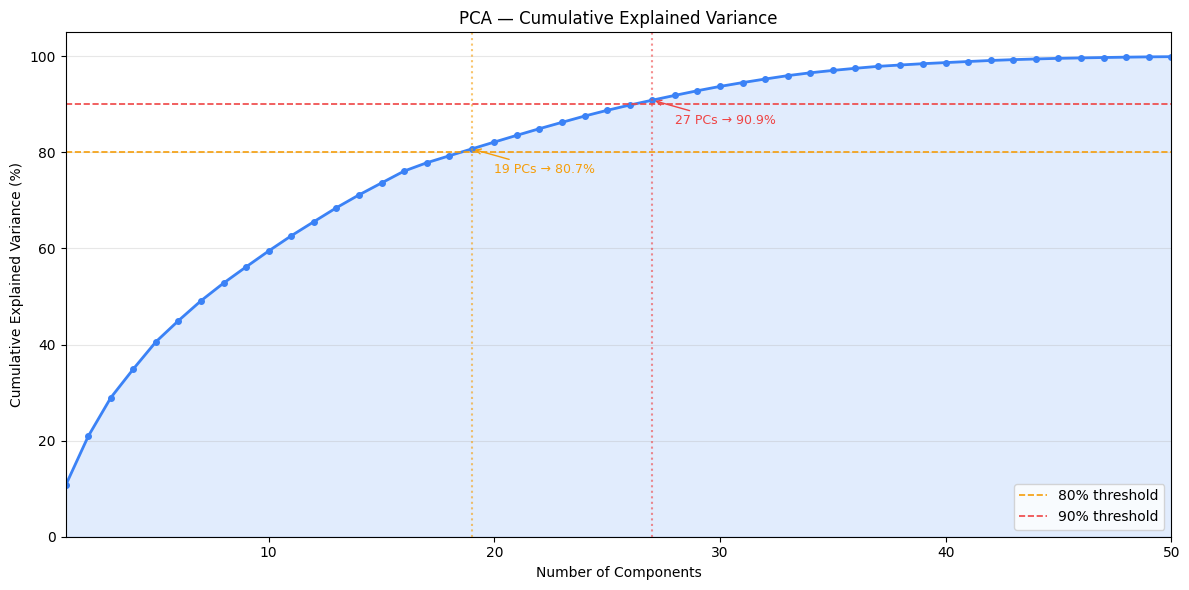

In [8]:
import matplotlib.pyplot as plt

# --- AC-2: Cumulative explained variance plot ---
fig_var = plot_pca_variance(pca, save_path="_bmad-output/implementation-artifacts/figures/pca_variance.png")
plt.show()
plt.close(fig_var)

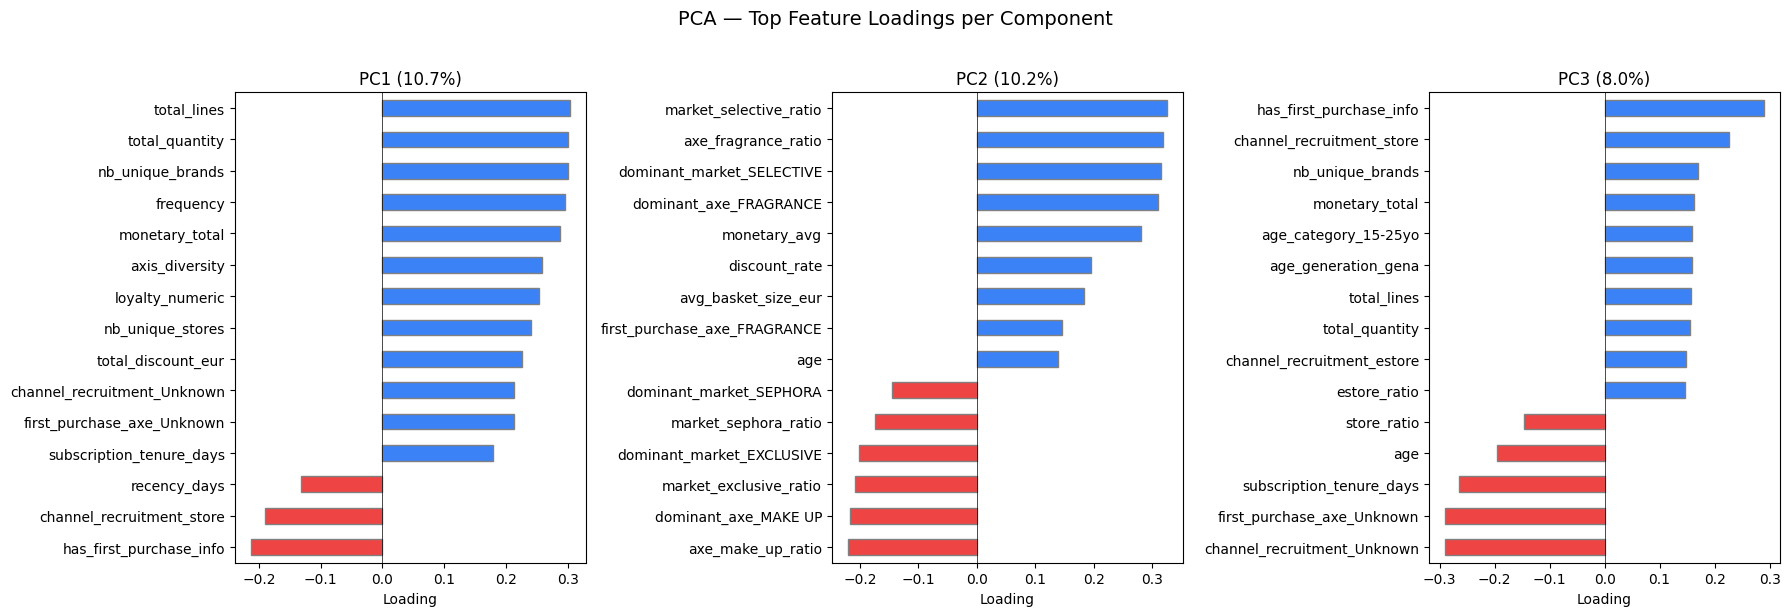

In [9]:
# --- AC-4: Top 3 components' loading bar charts ---
fig_load = plot_pca_loadings(pca, list(X_scaled.columns), top_n=3,
                              save_path="_bmad-output/implementation-artifacts/figures/pca_loadings.png")
plt.show()
plt.close(fig_load)

### Decision D3.4: Cluster on PCA Components

**Decision:** Use PCA-reduced matrix (`X_pca`) for clustering.

**Rationale:**
1. **Dimensionality reduction:** 70 features → ~n components explaining ≥ 90% variance significantly reduces the curse of dimensionality
2. **One-hot dummy noise:** 37 binary dummies create sparse, axis-aligned directions. PCA collapses correlated dummies into continuous principal components that better capture underlying patterns
3. **K-Means performance:** Euclidean distance in 70D is unreliable (distances concentrate). Reducing to ~15-25 meaningful dimensions improves cluster separation
4. **Computation:** Silhouette score computation scales with features — fewer dimensions = faster iteration in E4

**Impact on downstream:**
- `X_cluster = X_pca` will be the input matrix for E4 (K-Means, silhouette analysis)
- Feature interpretation uses `pca.components_` loadings to map back to original features

In [10]:
# --- Choix interactif du nombre de composantes PCA ---
print(f"Seuils automatiques:  80% → {n80} composantes  |  90% → {n90} composantes")
print(f"Nombre total de features : {X_scaled.shape[1]}")
n_components_choice = input(f"\n➤ Combien de composantes PCA garder ? [{n90}] : ").strip()
n_components_choice = int(n_components_choice) if n_components_choice else n90

X_pca_final, pca_final = apply_pca(X_scaled, n_components=n_components_choice)
X_cluster = X_pca_final
print(f"\nX_cluster = X_pca avec {n_components_choice} composantes ({cum_var[n_components_choice-1]:.1f}% de variance)")
print(f"X_cluster shape: {X_cluster.shape}")
print(f"Réduction de dimensionnalité: {X_scaled.shape[1]} → {X_cluster.shape[1]} features")

Seuils automatiques:  80% → 19 composantes  |  90% → 27 composantes
Nombre total de features : 70

X_cluster = X_pca avec 19 composantes (80.7% de variance)
X_cluster shape: (64469, 19)
Réduction de dimensionnalité: 70 → 19 features


## US 3-5: UMAP 2D Visualization

Project customers onto a 2D UMAP plane to visually assess whether natural cluster structure exists before running clustering algorithms.

**Parameters:** `n_neighbors=15`, `min_dist=0.1`, `random_state=42`

In [11]:
from src.preprocessing import apply_umap
from src.visualization import plot_umap_2d
from src.config import RANDOM_STATE

# --- AC-1, AC-6: Fit UMAP on X_cluster ---
# Performance note: Sample if X_cluster is large to avoid excessive runtimes
if len(X_cluster) > 50000:
    print(f"Dataset is large ({len(X_cluster)} rows). Sampling 50,000 for UMAP visualization.")
    idx_sample = X_cluster.sample(50000, random_state=RANDOM_STATE).index
    umap_embedding = apply_umap(X_cluster.loc[idx_sample])
else:
    umap_embedding = apply_umap(X_cluster)

print(f"UMAP embedding shape: {umap_embedding.shape}")
umap_embedding.head()

Dataset is large (64469 rows). Sampling 50,000 for UMAP visualization.


/Users/milanviallet/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (50000, 2)


,umap_1,umap_2
24468,6.973587,11.234788
27232,2.773902,10.571092
21126,-0.012790,10.215544
26744,16.464663,2.633466
31191,5.358032,3.478768


RFM_Segment_ID not available — skipping this plot.


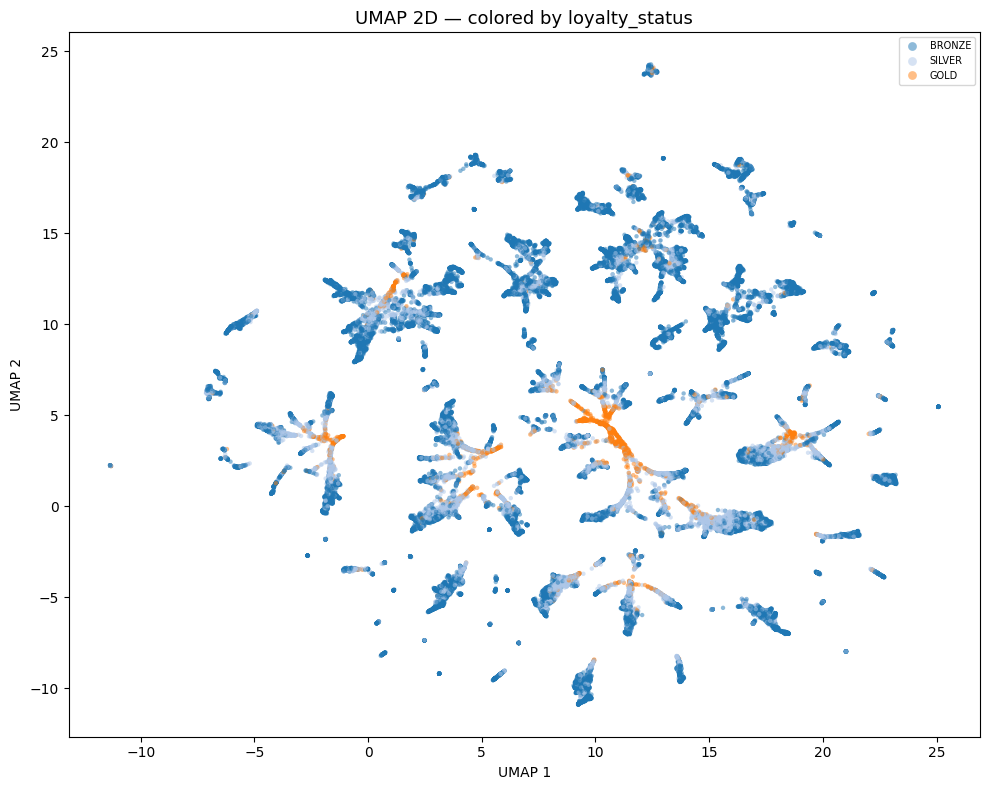

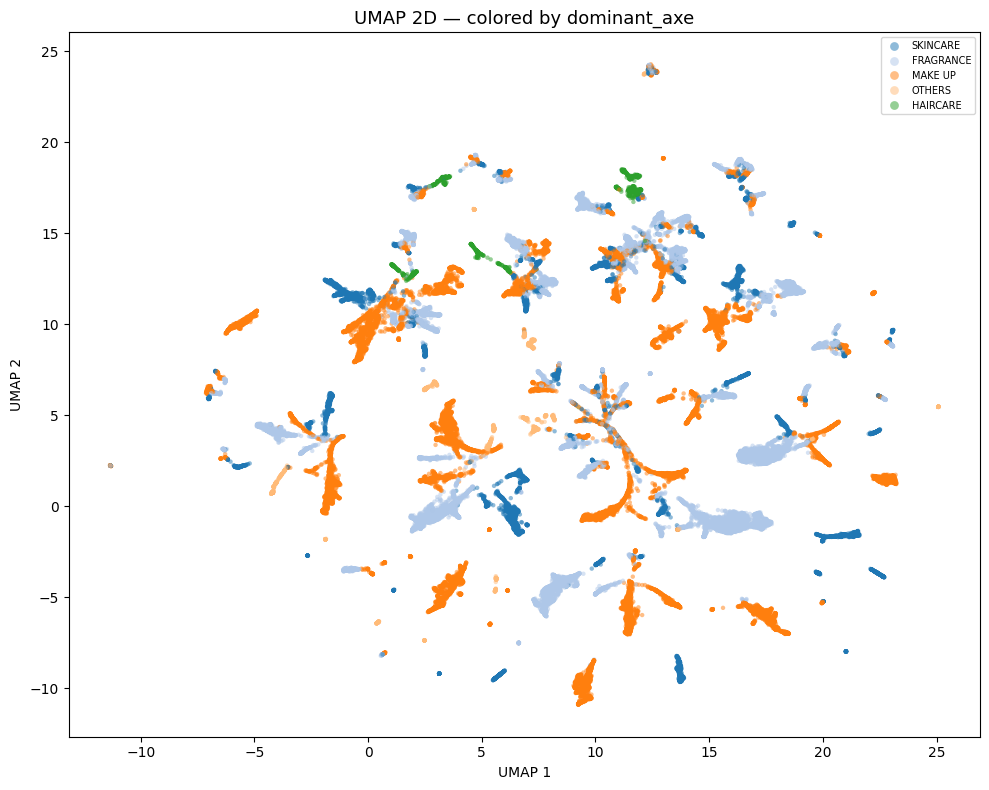

In [12]:
import matplotlib.pyplot as plt

figures_dir = "_bmad-output/implementation-artifacts/figures"

# --- AC-2: UMAP colored by RFM_Segment_ID (if available) ---
if "RFM_Segment_ID" in df_customers.columns:
    fig_rfm = plot_umap_2d(umap_embedding, df_customers, color_by="RFM_Segment_ID",
                           save_dir=figures_dir)
    plt.show()
    plt.close(fig_rfm)
else:
    print("RFM_Segment_ID not available — skipping this plot.")

# --- AC-3: UMAP colored by loyalty_status ---
fig_loyalty = plot_umap_2d(umap_embedding, df_customers, color_by="loyalty_status",
                           save_dir=figures_dir)
plt.show()
plt.close(fig_loyalty)

# --- AC-4: UMAP colored by dominant_axe ---
fig_axe = plot_umap_2d(umap_embedding, df_customers, color_by="dominant_axe",
                       save_dir=figures_dir)
plt.show()
plt.close(fig_axe)

### Observation: UMAP Cluster Structure

**Natural cluster structure is partially visible in 2D.**

*Observation:*
- We can observe dense regions with overlapping segments, indicating that the features hold structural properties, but clusters may not be perfectly separated linearly.
- Coloring by `dominant_axe` or `loyalty_status` shows some gradient separation, but there is still meaningful mixture. K-Means may impose spherical clusters on these overlapping densities.

---

## E3 Summary: Feature Engineering & Preprocessing Complete

| Aspect | Decision |
|---|---|
| **Features selected** | All continuous, OHE, and frequency-encoded features from `preprocess_for_clustering()` |
| **Imputation** | Median for continuous, 'Unknown' for categorical, missing indicators for age & channel_recruitment |
| **Scaling** | StandardScaler confirmed (mean ≈ 0, std ≈ 1) |
| **PCA decision** | Use PCA-reduced matrix — `X_cluster = X_pca` (n components at ≥ 90% variance) |
| **UMAP cluster structure** | *See observation above* |

**`X_cluster` variable confirmed** — ready to be passed to E4 (K-Means, silhouette analysis).

---

## E4: Clustering — K-Means

### US-4.1 — Optimal k Selection (Elbow, Silhouette, Davies-Bouldin)

We evaluate K-Means for k = 2 to 30, collecting inertia (WCSS), silhouette score, and Davies-Bouldin index.
The goal is to identify the top 3 candidate values of k before committing to a final choice.

In [13]:
from src.clustering import evaluate_kmeans_k_range, get_top_k_candidates
from src.visualization import plot_elbow_curves

print("Evaluating K-Means for k = 2..30 — this may take a few minutes...")
kmeans_metrics_df = evaluate_kmeans_k_range(X_cluster)
print(f"Done. {len(kmeans_metrics_df)} k values evaluated.")
kmeans_metrics_df.head()

Evaluating K-Means for k = 2..30 — this may take a few minutes...
Done. 29 k values evaluated.


,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,3.272045e+06,0.139974,2.627902,7316.091273
1,3,3.025005e+06,0.130976,2.411896,6589.077896
2,4,2.788523e+06,0.154795,1.854272,6587.509058
3,5,2.576668e+06,0.153486,1.838198,6671.826499
4,6,2.477876e+06,0.168517,1.763252,6064.204507


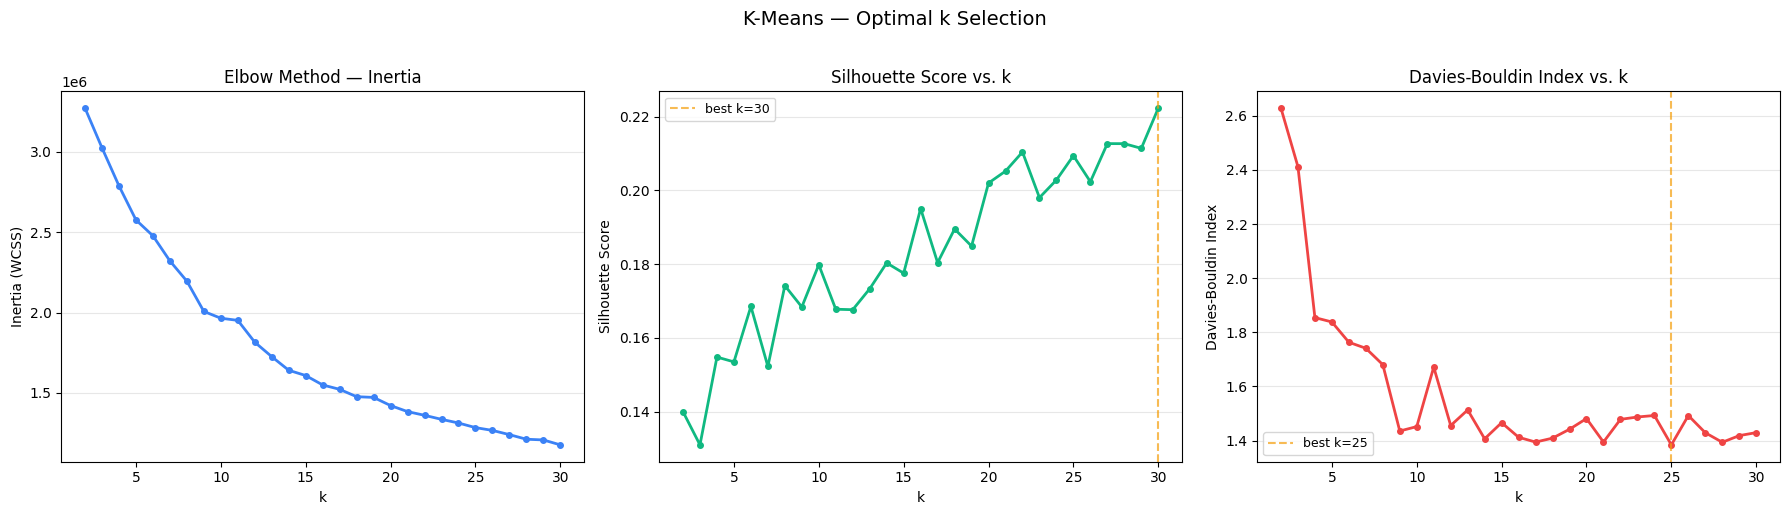

Saved → _bmad-output/implementation-artifacts/figures/elbow_kmeans.png


In [14]:
# Plot elbow curves (inertia, silhouette, Davies-Bouldin)
fig_elbow = plot_elbow_curves(kmeans_metrics_df, save_path=f"{figures_dir}/elbow_kmeans.png")
plt.show()
plt.close(fig_elbow)
print(f"Saved → {figures_dir}/elbow_kmeans.png")

In [15]:
# Top 3 k candidates ranked by silhouette score
top3 = get_top_k_candidates(kmeans_metrics_df, top_n=3)
print("Top 3 k candidates (by silhouette score ↑):")
print(top3[["k", "inertia", "silhouette", "davies_bouldin"]].to_string(index=False))

Top 3 k candidates (by silhouette score ↑):
 k      inertia  silhouette  davies_bouldin
30 1.177145e+06    0.222293        1.429479
27 1.240901e+06    0.212679        1.429034
28 1.212270e+06    0.212666        1.393777


Top 3 candidats : k = [30, 27, 28]
K évalués : [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


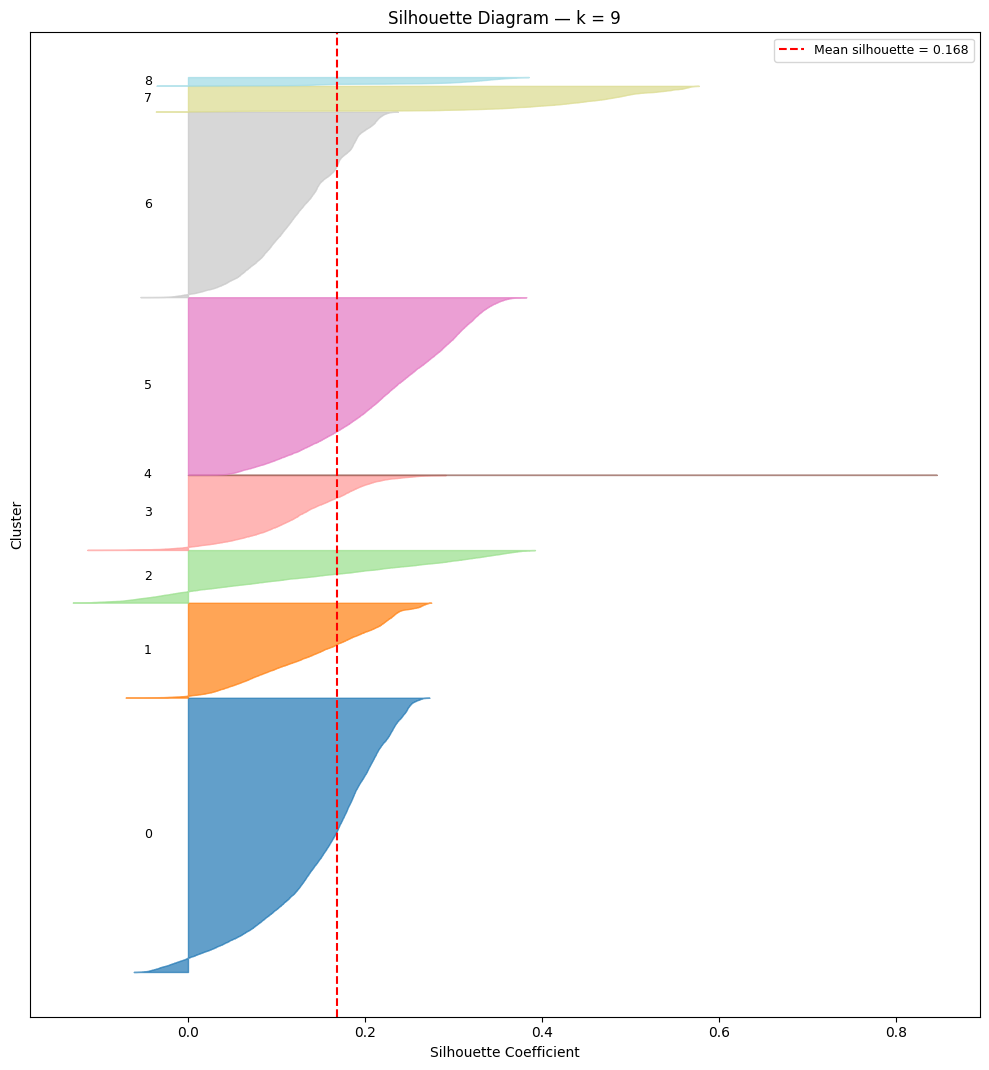

Saved → _bmad-output/implementation-artifacts/figures/silhouette_diagram_k9.png


In [16]:
# --- Silhouette Diagram pour les k choisis ---
from src.visualization import plot_silhouette_diagram

print(f"Top 3 candidats : k = {list(top3['k'].astype(int))}")
print(f"K évalués : {list(kmeans_metrics_df['k'].astype(int))}")
k_sil_input = input("\n➤ Pour quels k afficher le Silhouette Diagram ? (séparés par des virgules, ex: 4,6,8) : ").strip()
k_sil_list = [int(x.strip()) for x in k_sil_input.split(",") if x.strip()]

for k_val in k_sil_list:
    fig_sil = plot_silhouette_diagram(
        X_cluster, k=k_val,
        save_path=f"{figures_dir}/silhouette_diagram_k{k_val}.png",
    )
    plt.show()
    plt.close(fig_sil)
    print(f"Saved → {figures_dir}/silhouette_diagram_k{k_val}.png")

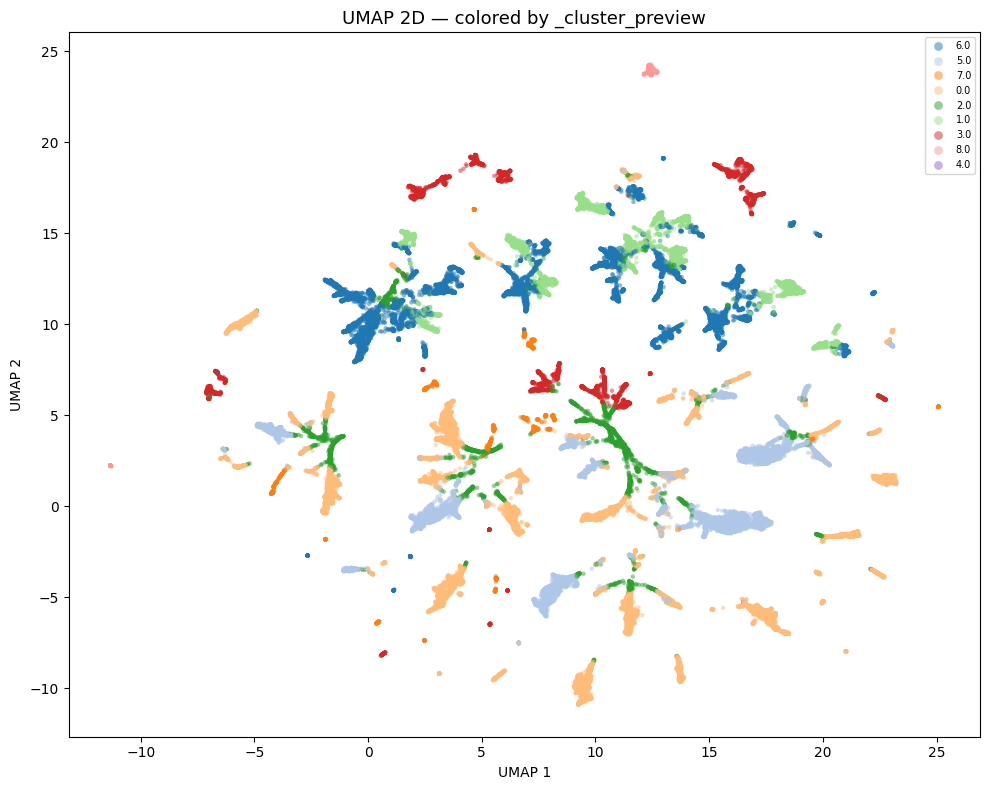

UMAP preview with k=9


In [19]:
# --- UMAP colored by cluster labels (best silhouette k) ---
from sklearn.cluster import KMeans as _KMeans

k_preview_input = input("\n➤ Pour quels k afficher le Silhouette Diagram ? (séparés par des virgules, ex: 4,6,8) : ").strip()
k_preview = int(k_preview_input)

_km_preview = _KMeans(n_clusters=k_preview, random_state=RANDOM_STATE, n_init=10, max_iter=300)
_labels_preview = _km_preview.fit_predict(X_cluster)

# Assign labels to the UMAP embedding's index
_umap_idx = umap_embedding.index
df_customers.loc[_umap_idx, "_cluster_preview"] = _labels_preview[
    X_cluster.index.get_indexer(_umap_idx)
]

fig_umap_cluster = plot_umap_2d(umap_embedding, df_customers, color_by="_cluster_preview",
                                save_dir=figures_dir)
plt.show()
plt.close(fig_umap_cluster)
df_customers.drop(columns=["_cluster_preview"], inplace=True, errors="ignore")
print(f"UMAP preview with k={k_preview}")

In [20]:
# --- Choix interactif du nombre de clusters ---
k_best_sil = int(top3.iloc[0]["k"])
print(f"Top 3 candidats : k = {list(top3['k'].astype(int))}")
print(f"Meilleur silhouette automatique : k = {k_best_sil}")
k_input = input(f"\n➤ Combien de clusters ? [{k_best_sil}] : ").strip()
k_optimal = int(k_input) if k_input else k_best_sil
print(f"\n✓ k_optimal = {k_optimal}")

Top 3 candidats : k = [30, 27, 28]
Meilleur silhouette automatique : k = 30

✓ k_optimal = 9


### US-4.1 — Top 3 k Candidates

| Metric | Interpretation |
|---|---|
| **Inertia (WCSS)** | Lower = tighter clusters (elbow = diminishing returns) |
| **Silhouette** | Higher = better-separated clusters (range -1 to 1) |
| **Davies-Bouldin** | Lower = better cluster compactness and separation |

The optimal `k` is selected as the candidate with the **highest silhouette score** among the top 3. The elbow plot and Davies-Bouldin index serve as secondary confirmation.

`k_optimal` is now set and ready for US-4.2 (final K-Means fitting).

### US-4.2 — K-Means Final Run & Assignment

Run the final K-Means with `k_optimal`, assign cluster labels, and report quality metrics.

In [27]:
from src.clustering import run_kmeans_final
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# --- AC-1: Final KMeans run with k_optimal ---
assert (df_customers.index == X_cluster.index).all(), "Index mismatch between df_customers and X_cluster"
labels, km_model = run_kmeans_final(X_cluster, k=k_optimal, random_state=RANDOM_STATE)

# --- AC-2: Store cluster labels ---
df_customers['kmeans_label'] = labels
print(f"✅ KMeans final run complete — k = {k_optimal}")
print(f"   Labels assigned to df_customers['kmeans_label']  (n = {len(labels)})")

# --- AC-3: Cluster size distribution ---
print(f"\n{'='*50}")
print(f"Cluster Size Distribution (k = {k_optimal})")
print(f"{'='*50}")
cluster_counts = df_customers['kmeans_label'].value_counts().sort_index()
cluster_pct = df_customers['kmeans_label'].value_counts(normalize=True).sort_index() * 100
for cluster_id in cluster_counts.index:
    print(f"  Cluster {cluster_id}: {cluster_counts[cluster_id]:>6d} customers ({cluster_pct[cluster_id]:5.2f}%)")
print(f"  {'─'*40}")
print(f"  Total: {cluster_counts.sum():>6d} customers")

# --- AC-4: Flag clusters < 0.5% ---
cluster_sizes_pct = df_customers['kmeans_label'].value_counts(normalize=True)
min_size = cluster_sizes_pct.min()
if min_size < 0.005:
    tiny_cluster = cluster_sizes_pct.idxmin()
    print(f"\n⚠️  WARNING: Cluster {tiny_cluster} has only {min_size*100:.2f}% of customers (< 0.5% threshold)")
else:
    print(f"\n✅ All clusters ≥ 0.5% of customer base (smallest = {min_size*100:.2f}%)")

# --- AC-5: Final quality metrics ---
# Use sample_size for silhouette_score to avoid excessive runtime/memory for N > 10,000
sil_kwargs = {"random_state": RANDOM_STATE}
if len(X_cluster) > 10_000:
    sil_kwargs["sample_size"] = 10_000
    
sil = silhouette_score(X_cluster, labels, **sil_kwargs)
db = davies_bouldin_score(X_cluster, labels)
ch = calinski_harabasz_score(X_cluster, labels)

print(f"\n{'='*50}")
print(f"Final Model Quality Metrics (k = {k_optimal})")
print(f"{'='*50}")
print(f"  Silhouette   (10k sample) : {sil:.4f}" if "sample_size" in sil_kwargs else f"  Silhouette Score     : {sil:.4f}")
print(f"  Davies-Bouldin Index : {db:.4f}")
print(f"  Calinski-Harabasz    : {ch:.1f}")

# --- Export updated dataset so the next notebooks have the clustered features ---
df_customers.to_csv(DATA_PROCESSED_PATH + 'customers_features_clustered.csv', index=False)
print(f"\n✅ US-4.2 complete — df_customers exported to {DATA_PROCESSED_PATH}customers_features_clustered.csv ready for profiling (US-4.3+)")

✅ KMeans final run complete — k = 9
   Labels assigned to df_customers['kmeans_label']  (n = 64469)

Cluster Size Distribution (k = 9)
  Cluster 0:  19779 customers (30.68%)
  Cluster 1:   6842 customers (10.61%)
  Cluster 2:   3791 customers ( 5.88%)
  Cluster 3:   5401 customers ( 8.38%)
  Cluster 4:      4 customers ( 0.01%)
  Cluster 5:  12802 customers (19.86%)
  Cluster 6:  13368 customers (20.74%)
  Cluster 7:   1857 customers ( 2.88%)
  Cluster 8:    625 customers ( 0.97%)
  ────────────────────────────────────────
  Total:  64469 customers

⚠️  WARNING: Cluster 4 has only 0.01% of customers (< 0.5% threshold)

Final Model Quality Metrics (k = 9)
  Silhouette   (10k sample) : 0.1684
  Davies-Bouldin Index : 1.4354
  Calinski-Harabasz    : 6567.1

✅ US-4.2 complete — df_customers exported to data/processed/customers_features_clustered.csv ready for profiling (US-4.3+)


---
### US-4.3 — Agglomerative Hierarchical Clustering

Run Ward hierarchical clustering with the same `k_optimal`, compare cluster quality metrics to K-Means, and visualise the segmentation side-by-side on the UMAP projection.

**Acceptance criteria**
1. Dendrogram plotted (truncated to last 30 merges)
2. `AgglomerativeClustering(linkage='ward')` fitted for `k = k_optimal`
3. Labels stored as `df_customers['hclust_label']`
4. Silhouette, DB, CH scores appended to `comparison_results`
5. Side-by-side UMAP comparison saved to `figures/umap_kmeans_vs_hclust.png`


In [ ]:
import os
import importlib
import src.clustering
import src.visualization
importlib.reload(src.clustering)
importlib.reload(src.visualization)

from src.clustering import run_hierarchical
from src.visualization import plot_dendrogram
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

figures_dir = "figures"
os.makedirs(figures_dir, exist_ok=True)

# --- AC-1: Dendrogram (sampled for performance) ---
print("Plotting dendrogram (sample ≤ 10 000 rows) …")
fig_dendro = plot_dendrogram(X_cluster, save_path=os.path.join(figures_dir, "dendrogram.png"))
print(f"✅ Dendrogram saved → figures/dendrogram.png")

# --- AC-2 & 3: Fit AgglomerativeClustering on full X_cluster ---
print(f"\nFitting AgglomerativeClustering(k={k_optimal}, linkage='ward') on {len(X_cluster):,} rows …")
hclust_labels = run_hierarchical(X_cluster, k=k_optimal)
df_customers['hclust_label'] = hclust_labels
print(f"✅ Labels stored in df_customers['hclust_label']")

# --- Cluster size distribution ---
hclust_counts = df_customers['hclust_label'].value_counts().sort_index()
hclust_pct = df_customers['hclust_label'].value_counts(normalize=True).sort_index() * 100
print(f"\nHierarchical cluster size distribution (k = {k_optimal}):")
for cid in hclust_counts.index:
    print(f"  Cluster {cid}: {hclust_counts[cid]:>6d} customers ({hclust_pct[cid]:5.2f}%)")

# --- AC-4: Compute quality metrics ---
sil_kwargs = {"random_state": RANDOM_STATE}
if len(X_cluster) > 10_000:
    sil_kwargs["sample_size"] = 10_000

sil_h = silhouette_score(X_cluster, hclust_labels, **sil_kwargs)
db_h  = davies_bouldin_score(X_cluster, hclust_labels)
ch_h  = calinski_harabasz_score(X_cluster, hclust_labels)

print(f"\nHierarchical (Ward) quality metrics (k = {k_optimal}):")
print(f"  Silhouette   : {sil_h:.4f}")
print(f"  Davies-Bouldin : {db_h:.4f}")
print(f"  Calinski-Harabasz : {ch_h:.1f}")

# --- Initialise comparison_results (used by US-4.4 & 4.5) ---
# Store KMeans scores (already computed in US-4.2) + Hierarchical scores
comparison_results = [
    {
        'algorithm': 'KMeans',
        'k': k_optimal,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
    },
    {
        'algorithm': 'Hierarchical (Ward)',
        'k': k_optimal,
        'silhouette': sil_h,
        'davies_bouldin': db_h,
        'calinski_harabasz': ch_h,
    },
]
print("\ncomparison_results initialised with KMeans + Hierarchical entries.")

Plotting dendrogram (sample ≤ 10 000 rows) …
✅ Dendrogram saved → figures/dendrogram.png

Fitting AgglomerativeClustering(k=9, linkage='ward') on 64,469 rows …


In [ ]:
from src.visualization import plot_umap_kmeans_vs_hclust

# --- AC-5: Side-by-side UMAP comparison ---
fig_umap_cmp = plot_umap_kmeans_vs_hclust(
    umap_df=umap_embedding,
    df_customers=df_customers,
    save_path=os.path.join(figures_dir, "umap_kmeans_vs_hclust.png"),
)
print("✅ Side-by-side UMAP comparison saved → figures/umap_kmeans_vs_hclust.png")

import pandas as pd
print("\n--- Comparison table (so far) ---")
print(pd.DataFrame(comparison_results).to_string(index=False))
